In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import data
import utils

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from finetune import ViTModelTrainer
from model import ResNet50Model, MobileNetV2, ViT16

import torch

/home/kuniko/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
# to reproduce
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [3]:
root = "../../dataset/CIFAKE/"
save_filepath = f'{root}train.csv'
df = pd.read_csv(save_filepath)
df_real = df[df['rf'] == 'REAL']
df_fake = df[df['rf'] == 'FAKE']

df_train_r, df_valid_r = train_test_split(df_real, test_size=0.2, random_state=42, shuffle=True)
df_train_r['image'] = df_train_r['filepath'].apply(os.path.basename)
df_valid_r['image'] = df_valid_r['filepath'].apply(os.path.basename)

df_train_f, df_valid_f = train_test_split(df_fake, test_size=0.2, random_state=42, shuffle=True)
df_train_f['image'] = df_train_f['filepath'].apply(os.path.basename)
df_valid_f['image'] = df_valid_f['filepath'].apply(os.path.basename)

save_filepath = f'{root}test.csv'
df_test = pd.read_csv(save_filepath)
df_test_r = df_test[df_test['rf'] == 'REAL']
df_test_f = df_test[df_test['rf'] == 'FAKE']
df_test_r['image'] = df_test_r['filepath'].apply(os.path.basename)
df_test_f['image'] = df_test_f['filepath'].apply(os.path.basename)

/tmp/ipykernel_689/377113202.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_r['image'] = df_test_r['filepath'].apply(os.path.basename)
/tmp/ipykernel_689/377113202.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_f['image'] = df_test_f['filepath'].apply(os.path.basename)


In [4]:
label_to_class=data.get_id_to_class()
num_class = len(label_to_class)

In [5]:
img_size = (224, 224)
batch_size = 32

label_encoder = LabelEncoder()
label_encoder.fit(df["label"])
train_loader_r = data.get_dataloader(df_train_r, img_size, batch_size, label_encoder, train=True)
valid_loader_r = data.get_dataloader(df_valid_r, img_size, batch_size, label_encoder, train=False)
test_loader_r = data.get_dataloader(df_test_r, img_size, batch_size, label_encoder, train=False)
train_loader_f = data.get_dataloader(df_train_f, img_size, batch_size, label_encoder, train=True)
valid_loader_f = data.get_dataloader(df_valid_f, img_size, batch_size, label_encoder, train=False)
test_loader_f = data.get_dataloader(df_test_f, img_size, batch_size, label_encoder, train=False)

/home/kuniko/notebooks/CIFAKE/data.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = label_encoder.transform(df["label"])
/home/kuniko/notebooks/CIFAKE/data.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = label_encoder.transform(df["label"])


# Real

../../dataset/CIFAKE/models/ViT16/real/ aready exist.
Sub folders of ../../dataset/CIFAKE/models/ViT16/real/ was deleted.
Epoch: 0 | Validation Accuracy: 0.7888 | Loss: 0.8099 | F1: 0.7885
Epoch: 1 | Validation Accuracy: 0.8737 | Loss: 0.4239 | F1: 0.8731
Epoch: 2 | Validation Accuracy: 0.8970 | Loss: 0.3273 | F1: 0.8969
Epoch: 3 | Validation Accuracy: 0.9052 | Loss: 0.2871 | F1: 0.9052
Epoch: 4 | Validation Accuracy: 0.9135 | Loss: 0.2572 | F1: 0.9132
Epoch: 5 | Validation Accuracy: 0.9214 | Loss: 0.2351 | F1: 0.9212
Epoch: 6 | Validation Accuracy: 0.9183 | Loss: 0.2486 | F1: 0.9186
Epoch: 7 | Validation Accuracy: 0.9224 | Loss: 0.2309 | F1: 0.9225
Epoch: 8 | Validation Accuracy: 0.9236 | Loss: 0.2296 | F1: 0.9237
Epoch: 9 | Validation Accuracy: 0.9314 | Loss: 0.2100 | F1: 0.9316
Epoch: 10 | Validation Accuracy: 0.9315 | Loss: 0.2205 | F1: 0.9318
Epoch: 11 | Validation Accuracy: 0.9351 | Loss: 0.2081 | F1: 0.9352
Epoch: 12 | Validation Accuracy: 0.9363 | Loss: 0.2031 | F1: 0.9365
Epoc

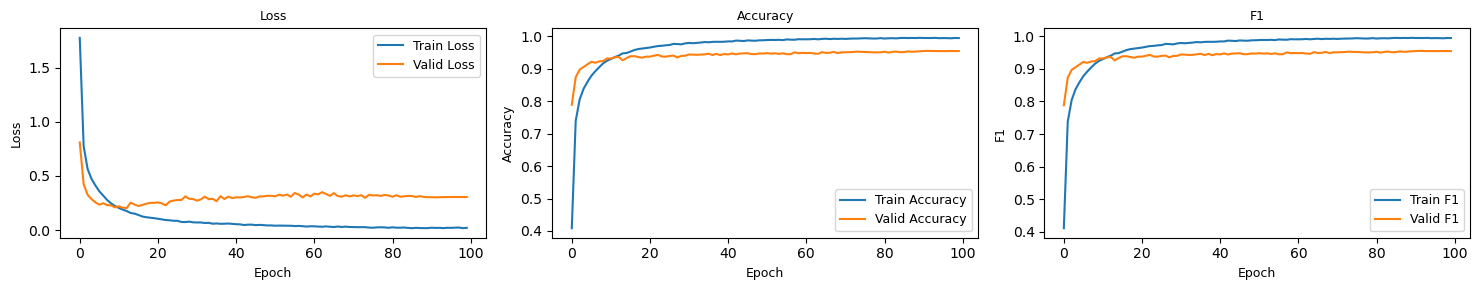

../../dataset/CIFAKE/models/ViT16/real/model_91.pt


In [18]:
model_name = 'ViT16'
setting = 'real'
model = ViT16(num_class)

model_save_directory = f"../../dataset/CIFAKE/models/{model_name}/{setting}/"
utils.create_directory(model_save_directory)
utils.delete_subfolders(model_save_directory)

num_epochs = 100
lr = 1e-5
trainer = ViTModelTrainer()
best_val_file = trainer.train(model, train_loader_r, valid_loader_r, model_save_directory, num_epochs=num_epochs, lr=lr)

In [19]:
model = ViT16(num_class)
model.load_state_dict(torch.load(best_val_file))

<All keys matched successfully>

In [20]:
display = True
out_filepath = None
trainer = ViTModelTrainer()
preds, test_outputs = trainer.evaluate(model, test_loader_r, display, out_filepath)
df_test_r['preds'] = preds
df_test_r.to_csv(f'{root}/results/{model_name}_{setting}_real.csv', index=False)

              precision  recall  f1-score     support
0              0.962889  0.9600  0.961442   1000.0000
1              0.970356  0.9820  0.976143   1000.0000
2              0.955193  0.9380  0.946519   1000.0000
3              0.906953  0.8870  0.896866   1000.0000
4              0.923828  0.9460  0.934783   1000.0000
5              0.903386  0.9070  0.905190   1000.0000
6              0.954635  0.9680  0.961271   1000.0000
7              0.973550  0.9570  0.965204   1000.0000
8              0.973134  0.9780  0.975561   1000.0000
9              0.971029  0.9720  0.971514   1000.0000
accuracy       0.949500  0.9495  0.949500      0.9495
macro avg      0.949495  0.9495  0.949449  10000.0000
weighted avg   0.949495  0.9495  0.949449  10000.0000


/tmp/ipykernel_208274/3379537671.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_r['preds'] = preds


In [21]:
display = True
out_filepath = None
trainer = ViTModelTrainer()
preds, test_outputs = trainer.evaluate(model, test_loader_f, display, out_filepath)
df_test_f['preds'] = preds
df_test_f.to_csv(f'{root}/results/{model_name}_{setting}_fake.csv', index=False)

              precision  recall  f1-score     support
0              0.796296  0.9890  0.882248   1000.0000
1              0.981946  0.9790  0.980471   1000.0000
2              0.948802  0.8710  0.908238   1000.0000
3              0.886686  0.9390  0.912093   1000.0000
4              0.953757  0.9900  0.971541   1000.0000
5              0.939286  0.7890  0.857609   1000.0000
6              0.987817  0.9730  0.980353   1000.0000
7              0.928846  0.9660  0.947059   1000.0000
8              0.971030  0.9050  0.936853   1000.0000
9              0.983140  0.9330  0.957414   1000.0000
accuracy       0.933400  0.9334  0.933400      0.9334
macro avg      0.937761  0.9334  0.933388  10000.0000
weighted avg   0.937761  0.9334  0.933388  10000.0000


/tmp/ipykernel_208274/2849099280.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_f['preds'] = preds


# Fake

../../dataset/CIFAKE/models/ViT16/fake aready exist.
Sub folders of ../../dataset/CIFAKE/models/ViT16/fake was deleted.
Epoch: 0 | Validation Accuracy: 0.9093 | Loss: 0.4166 | F1: 0.9095
Epoch: 1 | Validation Accuracy: 0.9614 | Loss: 0.1438 | F1: 0.9616
Epoch: 2 | Validation Accuracy: 0.9784 | Loss: 0.0739 | F1: 0.9785
Epoch: 3 | Validation Accuracy: 0.9789 | Loss: 0.0688 | F1: 0.9790
Epoch: 4 | Validation Accuracy: 0.9783 | Loss: 0.0629 | F1: 0.9783
Epoch: 5 | Validation Accuracy: 0.9835 | Loss: 0.0552 | F1: 0.9836
Epoch: 6 | Validation Accuracy: 0.9858 | Loss: 0.0424 | F1: 0.9859
Epoch: 7 | Validation Accuracy: 0.9886 | Loss: 0.0371 | F1: 0.9886
Epoch: 8 | Validation Accuracy: 0.9849 | Loss: 0.0505 | F1: 0.9849
Epoch: 9 | Validation Accuracy: 0.9861 | Loss: 0.0550 | F1: 0.9862
Epoch: 10 | Validation Accuracy: 0.9896 | Loss: 0.0394 | F1: 0.9896
Epoch: 11 | Validation Accuracy: 0.9880 | Loss: 0.0439 | F1: 0.9881
Epoch: 12 | Validation Accuracy: 0.9893 | Loss: 0.0455 | F1: 0.9894
Epoch:

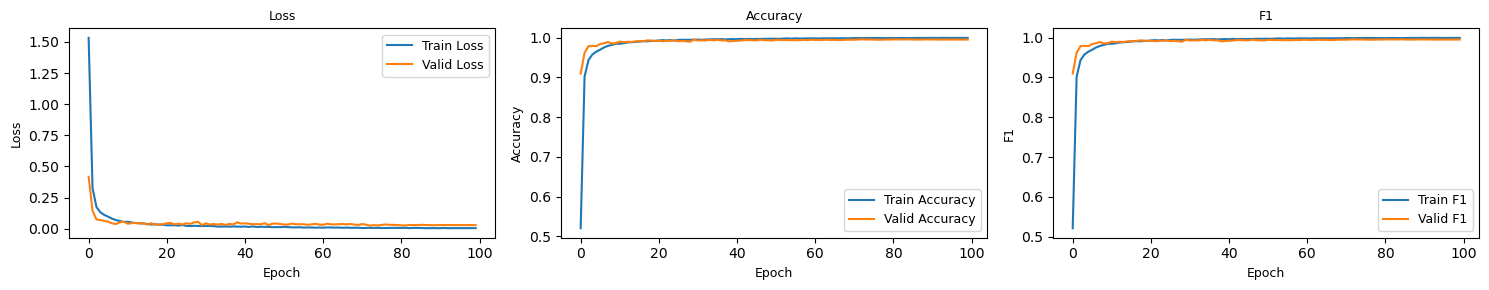

../../dataset/CIFAKE/models/ViT16/fakemodel_84.pt


In [6]:
model_name = 'ViT16'
setting = 'fake'
model = ViT16(num_class)

model_save_directory = f"../../dataset/CIFAKE/models/{model_name}/{setting}"
utils.create_directory(model_save_directory)
utils.delete_subfolders(model_save_directory)

num_epochs = 100
lr = 1e-5
trainer = ViTModelTrainer()
best_val_file = trainer.train(model, train_loader_f, valid_loader_f, model_save_directory, num_epochs=num_epochs, lr=lr)

In [7]:
model = ViT16(num_class)
model.load_state_dict(torch.load(best_val_file))

<All keys matched successfully>

In [8]:
display = True
out_filepath = None
trainer = ViTModelTrainer()
preds, test_outputs = trainer.evaluate(model, test_loader_r, display, out_filepath)
df_test_r['preds'] = preds
df_test_r.to_csv(f'{root}/results/{model_name}_{setting}_real.csv', index=False)

              precision  recall  f1-score     support
0              0.960848  0.5890  0.730316   1000.0000
1              0.910543  0.8550  0.881898   1000.0000
2              0.415944  0.7670  0.539381   1000.0000
3              0.578051  0.6110  0.594069   1000.0000
4              0.783871  0.4860  0.600000   1000.0000
5              0.595925  0.7020  0.644628   1000.0000
6              0.923345  0.2650  0.411810   1000.0000
7              0.686949  0.7790  0.730084   1000.0000
8              0.830999  0.8900  0.859488   1000.0000
9              0.739061  0.9290  0.823217   1000.0000
accuracy       0.687300  0.6873  0.687300      0.6873
macro avg      0.742554  0.6873  0.681489  10000.0000
weighted avg   0.742554  0.6873  0.681489  10000.0000


/tmp/ipykernel_689/3379537671.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_r['preds'] = preds


In [9]:
display = True
out_filepath = None
trainer = ViTModelTrainer()
preds, test_outputs = trainer.evaluate(model, test_loader_f, display, out_filepath)
df_test_f['preds'] = preds
df_test_f.to_csv(f'{root}/results/{model_name}_{setting}_fake.csv', index=False)

              precision  recall  f1-score     support
0              0.994006  0.9950  0.994503   1000.0000
1              0.996016  1.0000  0.998004   1000.0000
2              0.994975  0.9900  0.992481   1000.0000
3              0.987026  0.9890  0.988012   1000.0000
4              0.998999  0.9980  0.998499   1000.0000
5              0.989980  0.9880  0.988989   1000.0000
6              0.999001  1.0000  0.999500   1000.0000
7              1.000000  1.0000  1.000000   1000.0000
8              0.988072  0.9940  0.991027   1000.0000
9              0.997988  0.9920  0.994985   1000.0000
accuracy       0.994600  0.9946  0.994600      0.9946
macro avg      0.994606  0.9946  0.994600  10000.0000
weighted avg   0.994606  0.9946  0.994600  10000.0000


/tmp/ipykernel_689/2849099280.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_f['preds'] = preds
